In [2]:
# Cell 1 - Setup: install CatBoost if needed, imports, paths
import importlib.util
if importlib.util.find_spec("catboost") is None:
    !pip install catboost --quiet

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from models.utils import (
    chronological_split,
    select_enhanced_features,
    TARGET_REG,
    TARGET_CLASS,
    regression_report,
    classification_report,
    apply_feature_transforms,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

FEATURES = PROJECT_ROOT / "data" / "features"


In [11]:
df = pd.read_parquet(FEATURES / "feature_matrix_engineered_v2.parquet")
df

,HB_HOUSTON,HB_NORTH,HB_SOUTH,HB_WEST,HB_HUBAVG,price_spike_flag,da_HB_HOUSTON,da_HB_NORTH,da_HB_SOUTH,da_HB_WEST,da_HB_HUBAVG,Houston_temperature_2m,Houston_relative_humidity_2m,Houston_cloud_cover,Houston_wind_speed_10m,Houston_wind_gusts_10m,Houston_precipitation,North (Dallas)_temperature_2m,North (Dallas)_relative_humidity_2m,North (Dallas)_cloud_cover,North (Dallas)_wind_speed_10m,North (Dallas)_wind_gusts_10m,North (Dallas)_precipitation,South (San Antonio)_temperature_2m,South (San Antonio)_relative_humidity_2m,South (San Antonio)_cloud_cover,South (San Antonio)_wind_speed_10m,South (San Antonio)_wind_gusts_10m,South (San Antonio)_precipitation,West (Midland)_temperature_2m,West (Midland)_relative_humidity_2m,West (Midland)_cloud_cover,West (Midland)_wind_speed_10m,West (Midland)_wind_gusts_10m,West (Midland)_precipitation,load_actual_mw,gdelt_tone,gdelt_norm,gdelt_article_volume,gdelt_tone_lag_1d,gdelt_tone_lag_2d,gdelt_tone_lag_3d,gdelt_volume_lag_1d,gdelt_volume_lag_2d,gdelt_tone_change_1d,gdelt_tone_change_3d,gdelt_volume_change_1d,gdelt_volume_change_3d,gdelt_volume_zscore_30d,gdelt_tone_zscore_30d,henry_hub_price,henry_hub_lag_1d,henry_hub_change_1d,henry_hub_change_7d,reactor_comanche_peak_1_pct,reactor_comanche_peak_2_pct,reactor_south_texas_1_pct,reactor_south_texas_2_pct,reactors_offline_pct_sum,reactors_offline_change_1d,storage_bcf,storage_wow_change,storage_bcf_lag_1w,hubavg_lag_1h,hubavg_lag_12h,hubavg_lag_24h,hubavg_lag_48h,hubavg_lag_168h,hubavg_lag_720h,hubavg_rollmean_24h,hubavg_rollstd_24h,hubavg_rollmean_168h,hubavg_rollstd_168h,load_lag_1h,load_rollmean_24h,temp_min_across_zones,temp_max_across_zones,temp_range_across_zones,wind_mean_across_zones,wind_min_across_zones,stress_cold_snap,stress_freeze,stress_heat_wave,stress_extreme_heat,stress_low_wind,stress_gas_spike,stress_reactor_outage,stress_score,hour,day_of_week,month,is_weekend,is_peak_hours,future_spike_24h,future_price_max_24h
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-31 06:00:00+00:00,-1.04,-1.05,-1.03,-0.94,-1.02,False,6.25,6.22,6.07,4.93,5.87,62.4,83,86,12.7,21.5,0.0,59.6,72,0,19.3,33.1,0.0,57.7,90,46,8.7,15.7,0.0,58.0,23,0,13.5,23.7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.28,2.28,0.00,0.07,100.0,100.0,100.0,100.0,0.0,-86.0,2934,-152.0,3086.0,-0.54,15.90,17.91,13.16,10.62,15.50,14.068333,5.514643,21.111488,33.152110,NaN,NaN,57.7,62.4,4.7,13.550,8.7,0,0,0,0,0,0,0,0,6,6,1,1,0,0,31.42
2016-01-31 07:00:00+00:00,-15.93,-15.93,-15.93,-15.93,-15.93,False,5.67,5.58,5.52,4.84,5.40,63.3,84,89,12.2,22.1,0.0,59.1,77,0,18.6,32.2,0.0,57.1,92,0,7.8,15.7,0.0,57.0,24,0,13.3,21.7,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.28,2.28,0.00,0.07,100.0,100.0,100.0,100.0,0.0,-86.0,2934,-152.0,3086.0,-1.02,14.24,17.16,12.71,10.53,15.37,13.279583,6.246487,21.042202,33.186314,NaN,NaN,57.0,63.3,6.3,12.975,7.8,0,0,0,0,0,0,0,0,7,6,1,1,0,0,31.42
2016-01-31 08:00:00+00:00,-10.91,-10.91,-10.91,-10.90,-10.91,False,5.63,5.54,5.49,4.87,5.38,63.0,84,93,11.8,21.5,0.0,58.4,82,0,18.3,31.3,0.0,56.0,95,0,6.7,13.4,0.0,56.8,25,0,14.5,22.8,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.28,2.28,0.00,0.07,100.0,100.0,100.0,100.0,0.0,-86.0,2934,-152.0,3086.0,-15.93,12.98,16.99,12.63,10.88,15.11,11.900833,8.571812,20.884702,33.299100,NaN,NaN,56.0,63.0,7.0,12.825,6.7,0,0,0,0,0,0,0,0,8,6,1,1,0,0,31.42
2016-01-31 09:00:00+00:00,-1.32,-1.32,-1.32,-1.32,-1.32,False,5.32,5.23,5.24,4.94,5.18,62.4,86,97,11.7,20.6,0.0,57.9,85,0,17.7,30.6,0.0,54.9,96,4,6.4,11.4,0.0,57.8,24,0,16.6,26.2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.28,2.28,0.00,0.07,100.0,100.0,100.0,100.0,0.0,-86.0,2934,-152.0,3086.0,-10.91,4.78,17.33,13.39,13.59,15.06,10.738333,9.672795,20.755000,33.380639,NaN,NaN,54.9,62.4,7.5,13.100,6.4,0,0,0,0,0,0,0,0,9,6,1,1,0,0,31.42
2016-01-31 10:00:00+00:00,-1.00,-1.00,-1.00,-1.00,-1.00,False,5.21,5.11,5.19,5.01,5.13,62.2,87,98,12.0,1

In [3]:
# Cell 2 - Load feature matrix, chronological split, feature list
mat = pd.read_parquet(FEATURES / "feature_matrix_engineered_v2.parquet")
mat = apply_feature_transforms(mat)
train, val, test = chronological_split(mat)

features = select_enhanced_features(mat)
print(f"\n{len(features)} features selected")
print("First 10:", features[:10], "...")
print("Last 10: ", features[-10:])


  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,429 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)

63 features selected
First 10: ['da_HB_HOUSTON', 'da_HB_HUBAVG', 'da_HB_NORTH', 'da_HB_SOUTH', 'da_HB_WEST', 'day_of_week', 'gdelt_article_volume', 'gdelt_norm', 'gdelt_tone', 'gdelt_tone_change_1d'] ...
Last 10:  ['stress_gas_spike', 'stress_heat_wave', 'stress_low_wind', 'stress_reactor_outage', 'stress_score', 'temp_max_across_zones', 'temp_min_across_zones', 'temp_range_across_zones', 'wind_mean_across_zones', 'wind_min_across_zones']


In [4]:
# Cell 3 - Shared model arrays for regression and classification
df_reg = mat.dropna(subset=[TARGET_REG])
tr_reg, vl_reg, te_reg = chronological_split(df_reg)

X_train_r = tr_reg[features].ffill().fillna(0);  y_train_r = tr_reg[TARGET_REG]
X_val_r   = vl_reg[features].ffill().fillna(0);  y_val_r   = vl_reg[TARGET_REG]
X_test_r  = te_reg[features].ffill().fillna(0);  y_test_r  = te_reg[TARGET_REG]

df_clf = mat.dropna(subset=[TARGET_CLASS])
tr_clf, vl_clf, te_clf = chronological_split(df_clf)

X_train_c = tr_clf[features].ffill().fillna(0);  y_train_c = tr_clf[TARGET_CLASS]
X_val_c   = vl_clf[features].ffill().fillna(0);  y_val_c   = vl_clf[TARGET_CLASS]
X_test_c  = te_clf[features].ffill().fillna(0);  y_test_c  = te_clf[TARGET_CLASS]

print(f"Regression arrays:     X_train={X_train_r.shape}, X_val={X_val_r.shape}, X_test={X_test_r.shape}")
print(f"Classification arrays: X_train={X_train_c.shape}, X_val={X_val_c.shape}, X_test={X_test_c.shape}")


  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,428 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)
  Split boundaries:
    Train: 2016-01-31 06:00:00+00:00 → 2022-12-31 23:00:00+00:00 (60,429 rows)
    Val:   2023-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00 (8,760 rows)
    Test:  2024-01-01 00:00:00+00:00 → 2024-12-31 06:00:00+00:00 (8,767 rows)
Regression arrays:     X_train=(60428, 63), X_val=(8760, 63), X_test=(8767, 63)
Classification arrays: X_train=(60429, 63), X_val=(8760, 63), X_test=(8767, 63)


In [5]:
# Cell 4 - CatBoost Regressor (HB_HUBAVG)
cat_features = []

reg = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    subsample=0.8,
    rsm=0.8,
    random_seed=42,
    verbose=False,
    early_stopping_rounds=25,
    loss_function="RMSE",
)
reg.fit(
    X_train_r,
    y_train_r,
    eval_set=(X_val_r, y_val_r),
    cat_features=cat_features,
)

y_pred_test_r = reg.predict(X_test_r)
print("\nTest-set metrics:")
reg_report = regression_report(y_test_r.values, y_pred_test_r, name="catboost_enhanced_v2_regressor test")



Test-set metrics:

--- Regression report: catboost_enhanced_v2_regressor test ---
  MAE:             $20.90/MWh
  RMSE:            $101.54/MWh
  Spike recall:    44.74%
  Spike precision: 48.11%
---------------------------------



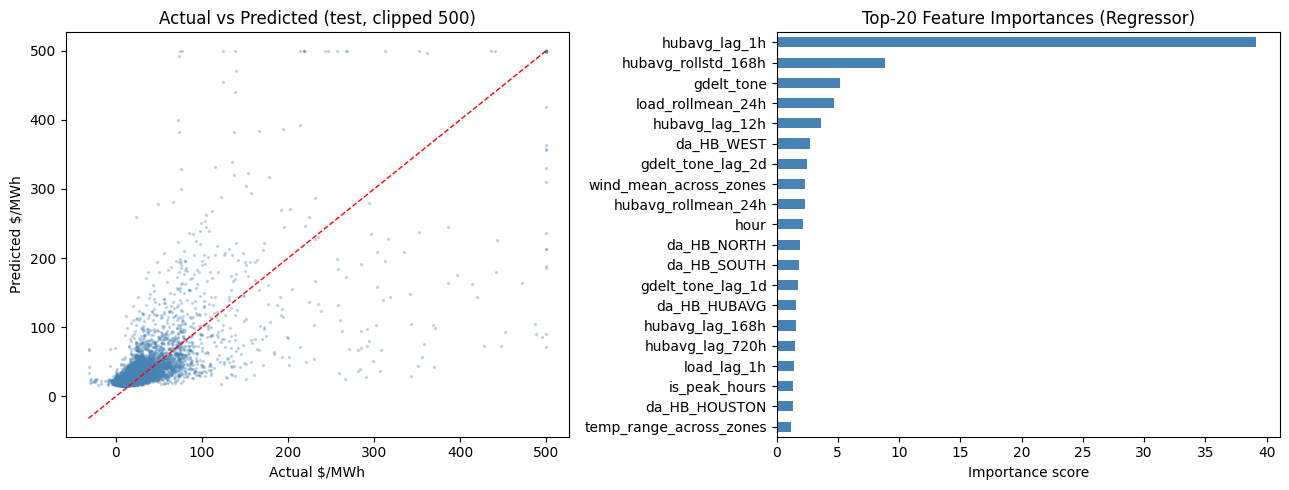

In [6]:
# Cell 5 - Regressor plots: actual vs predicted and top-20 feature importance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clip_hi = 500
axes[0].scatter(
    y_test_r.clip(-50, clip_hi),
    np.clip(y_pred_test_r, -50, clip_hi),
    s=2,
    alpha=0.25,
    color="steelblue",
)
lo = min(y_test_r.clip(-50, clip_hi).min(), np.clip(y_pred_test_r, -50, clip_hi).min())
hi = max(y_test_r.clip(-50, clip_hi).max(), np.clip(y_pred_test_r, -50, clip_hi).max())
axes[0].plot([lo, hi], [lo, hi], "r--", lw=1)
axes[0].set_title("Actual vs Predicted (test, clipped 500)")
axes[0].set_xlabel("Actual $/MWh")
axes[0].set_ylabel("Predicted $/MWh")

reg_importance = pd.Series(reg.get_feature_importance(), index=features).sort_values(ascending=False)
reg_importance.head(20).sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Top-20 Feature Importances (Regressor)")
axes[1].set_xlabel("Importance score")

plt.tight_layout()
plt.show()


In [7]:
# Cell 6 - CatBoost Classifier (future_spike_24h)
clf = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    subsample=0.8,
    rsm=0.8,
    random_seed=42,
    verbose=False,
    early_stopping_rounds=25,
    loss_function="Logloss",
    auto_class_weights="Balanced",
)
clf.fit(
    X_train_c,
    y_train_c,
    eval_set=(X_val_c, y_val_c),
    cat_features=cat_features,
)

val_proba = clf.predict_proba(X_val_c)[:, 1]
test_proba = clf.predict_proba(X_test_c)[:, 1]

print("\nValidation metrics:")
val_report = classification_report(y_val_c.values, val_proba, name="catboost_enhanced_v2_classifier val", threshold=0.5)

print("\nThreshold sweep on test set:")
threshold_reports = {}
for threshold in [0.3, 0.4, 0.5, 0.6]:
    threshold_reports[threshold] = classification_report(
        y_test_c.values,
        test_proba,
        name=f"catboost_enhanced_v2_classifier test@{threshold}",
        threshold=threshold,
    )



Validation metrics:

--- Classification report: catboost_enhanced_v2_classifier val ---
  PR-AUC:    0.519
  ROC-AUC:   0.659
  Recall:    55.12%  (at threshold 0.5)
  Precision: 40.59%
  Confusion: TP=1411  FP=2065  FN=1149  TN=4135
-------------------------------------


Threshold sweep on test set:

--- Classification report: catboost_enhanced_v2_classifier test@0.3 ---
  PR-AUC:    0.248
  ROC-AUC:   0.586
  Recall:    83.81%  (at threshold 0.3)
  Precision: 17.21%
  Confusion: TP=1232  FP=5925  FN=238  TN=1372
-------------------------------------


--- Classification report: catboost_enhanced_v2_classifier test@0.4 ---
  PR-AUC:    0.248
  ROC-AUC:   0.586
  Recall:    61.77%  (at threshold 0.4)
  Precision: 19.48%
  Confusion: TP=908  FP=3753  FN=562  TN=3544
-------------------------------------


--- Classification report: catboost_enhanced_v2_classifier test@0.5 ---
  PR-AUC:    0.248
  ROC-AUC:   0.586
  Recall:    37.28%  (at threshold 0.5)
  Precision: 25.81%
  Confusion:

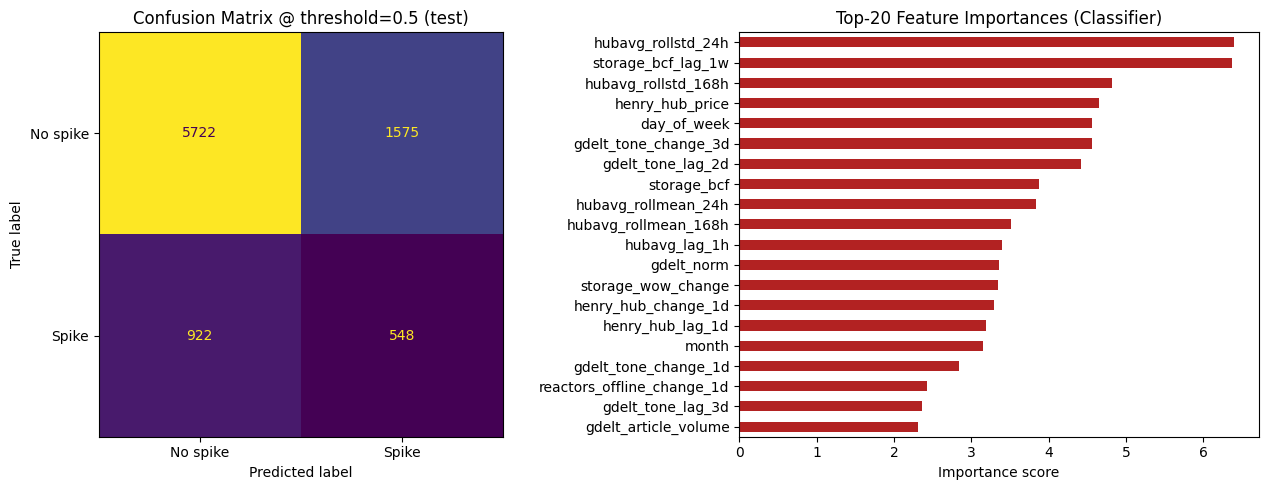

In [8]:
# Cell 7 - Classifier plots: confusion matrix at 0.5 and top-20 feature importance
cm = confusion_matrix(y_test_c, (test_proba >= 0.5).astype(int), labels=[0, 1])
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=["No spike", "Spike"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix @ threshold=0.5 (test)")

clf_importance = pd.Series(clf.get_feature_importance(), index=features).sort_values(ascending=False)
clf_importance.head(20).sort_values().plot.barh(ax=axes[1], color="firebrick")
axes[1].set_title("Top-20 Feature Importances (Classifier)")
axes[1].set_xlabel("Importance score")

plt.tight_layout()
plt.show()


In [9]:
# Cell 8 - Probability distribution spot-check
qs = np.quantile(test_proba, [0, 0.25, 0.5, 0.75, 1.0])
print("Test-set probability distribution:")
print(f"  min={qs[0]:.3f}  Q1={qs[1]:.3f}  median={qs[2]:.3f}  Q3={qs[3]:.3f}  max={qs[4]:.3f}")


Test-set probability distribution:
  min=0.154  Q1=0.327  median=0.410  Q3=0.497  max=0.854


In [ ]:
from sklearn.metrics import average_precision_score
import numpy as np
_y_true_dollar = np.asarray(y_test_r).reshape(-1)
_y_pred_dollar = np.asarray(y_pred_test_r).reshape(-1)
_spike_pr_auc = average_precision_score(
    (_y_true_dollar > 200).astype(int),
    _y_pred_dollar,
)
print(f"\n=== Bake-off PR-AUC (regressor-as-score, threshold $200) ===")
print(f"  Spike PR-AUC: {_spike_pr_auc:.3f}")

In [ ]:
# Final — Feature importance histogram (CatBoost regressor)
# Dedicated full-width view of which inputs the CatBoost regressor leans on.
import matplotlib.pyplot as plt

cat_importance = pd.Series(reg.get_feature_importance(), index=features).sort_values(ascending=False)
top20 = cat_importance.head(20).sort_values()  # ascending so largest is at top of horizontal bar chart

fig, ax = plt.subplots(figsize=(11, 8))
top20.plot.barh(ax=ax, color="steelblue", edgecolor="white")
ax.set_title("CatBoost regressor — top 20 feature importances", fontsize=14, pad=12)
ax.set_xlabel("Importance score")
ax.set_ylabel("")
for i, (name, val) in enumerate(zip(top20.index, top20.values)):
    ax.text(val, i, f"  {val:.2f}", va="center", fontsize=9, color="dimgray")
plt.tight_layout()
plt.show()

print("\nTop 20 features by CatBoost importance:")
for rank, (name, val) in enumerate(cat_importance.head(20).items(), start=1):
    print(f"  {rank:2d}. {name:40s} {val:.4f}")
